In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm # 进度条工具

import torch
import torch.nn as nn
import torch.nn.functional as F
# transforms提供了数据处理工具
import torchvision.transforms as transforms 
# 由于数据集较大，我们通过工具在线下载数据集
from torchvision.datasets import CIFAR10 
from torch.utils.data import DataLoader

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting ./cifar10\cifar-10-python.tar.gz to ./cifar10
Files already downloaded and verified
训练集大小： 50000
测试集大小： 10000


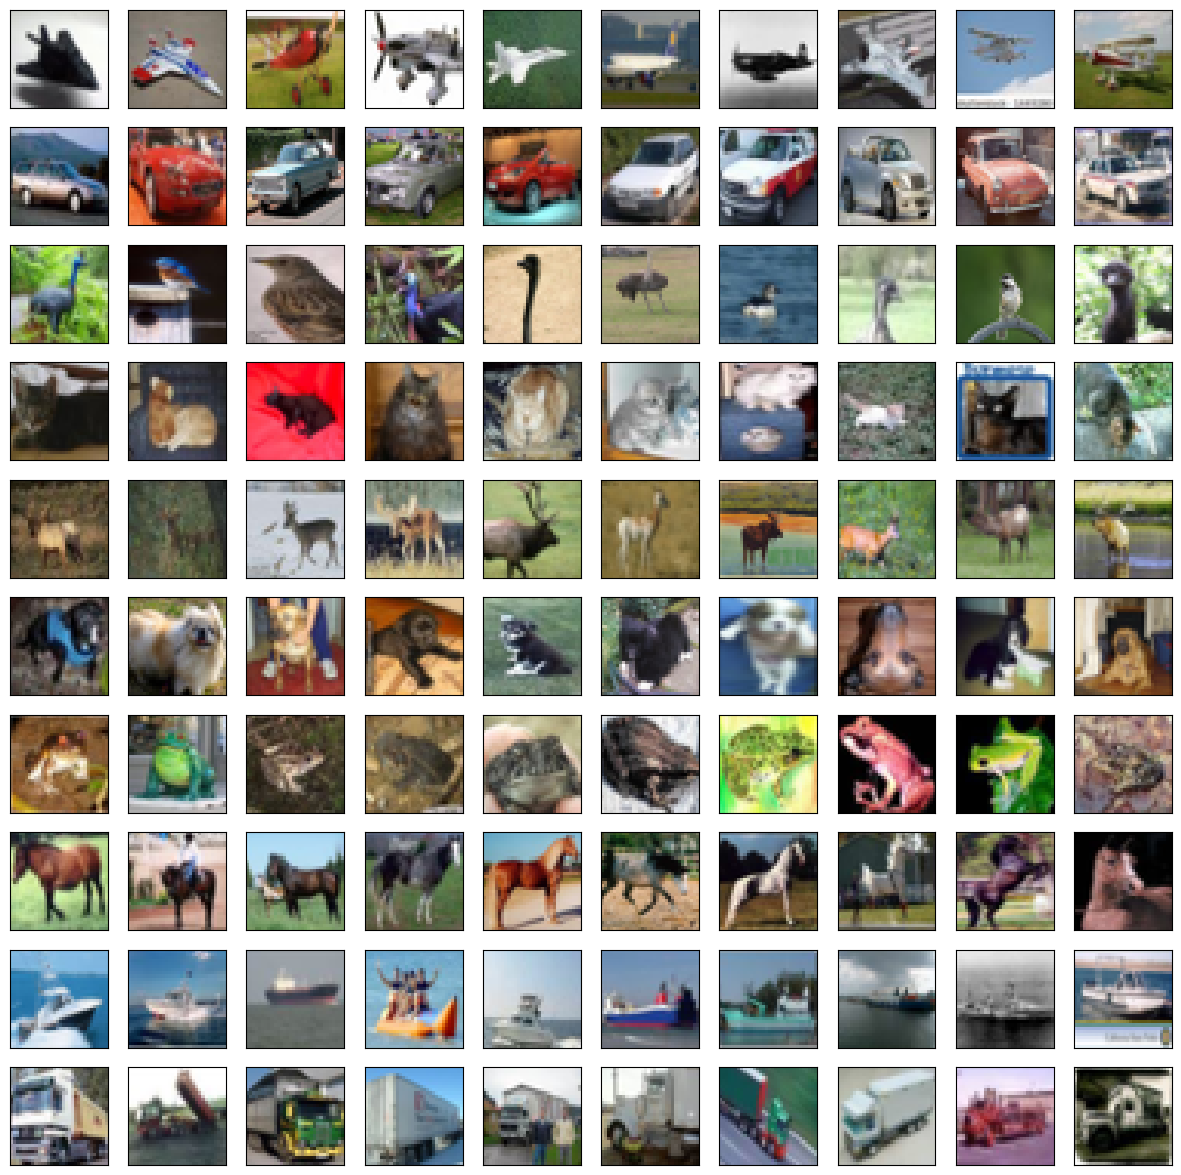

In [2]:
# 下载训练集和测试集
data_path = './cifar10'
trainset = CIFAR10(root=data_path, train=True, 
    download=True, transform=transforms.ToTensor())
testset = CIFAR10(root=data_path, train=False, 
    download=True, transform=transforms.ToTensor())
print('训练集大小：', len(trainset))
print('测试集大小：', len(testset))
# trainset和testset可以直接用下标访问
# 每个样本为一个元组 (data, label)
# data是3*32*32的Tensor，表示图像
# label是0-9之间的整数，代表图像的类别

# 可视化数据集
num_classes = 10
fig, axes = plt.subplots(num_classes, 10, figsize=(15, 15))
labels = np.array([t[1] for t in trainset]) # 取出所有样本的标签
for i in range(num_classes):
    indice = np.where(labels == i)[0] # 类别为i的图像的下标
    for j in range(10): # 展示前10张图像
        # matplotlib绘制RGB图像时
        # 图像矩阵依次是宽、高、颜色，与数据集中有差别
        # 因此需要用permute重排数据的坐标轴
        axes[i][j].imshow(trainset[indice[j]][0].permute(1, 2, 0).numpy())
        # 去除坐标刻度
        axes[i][j].set_xticks([]) 
        axes[i][j].set_yticks([])
plt.show()

In [3]:
class CNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()
        # 类别数目
        self.num_classes = num_classes
        # Conv2D为二维卷积层，参数依次为
        # in_channels：输入通道
        # out_channels：输出通道，即卷积核个数
        # kernel_size：卷积核大小，默认为正方形
        # padding：填充层数，padding=1表示对输入四周各填充一层，默认填充0
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, 
            kernel_size=3, padding=1)
        # 第二层卷积，输入通道与上一层的输出通道保持一致
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        # 最大池化，kernel_size表示窗口大小，默认为正方形
        self.pooling1 = nn.MaxPool2d(kernel_size=2)
        # 丢弃层，p表示每个位置被置为0的概率
        # 随机丢弃只在训练时开启，在测试时应当关闭
        self.dropout1 = nn.Dropout(p=0.25)
        
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)
        self.pooling2 = nn.MaxPool2d(2)
        self.dropout2 = nn.Dropout(0.25)

        # 全连接层，输入维度4096=64*8*8，与上一层的输出一致
        self.fc1 = nn.Linear(4096, 512)
        self.dropout3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    # 前向传播，将输入按顺序依次通过设置好的层
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pooling1(x)
        x = self.dropout1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pooling2(x)
        x = self.dropout2(x)

        # 全连接层之前，将x的形状转为 (batch_size, n)
        x = x.view(len(x), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x)
        return x

In [4]:
batch_size = 64 # 批量大小
learning_rate = 1e-3 # 学习率
epochs = 5 # 训练轮数
np.random.seed(0)
torch.manual_seed(0)

# 批量生成器
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)

model = CNN()
# 使用Adam优化器
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
# 使用交叉熵损失
criterion = F.cross_entropy

# 开始训练
for epoch in range(epochs):
    losses = 0
    accs = 0
    num = 0
    model.train() # 将模型设置为训练模式，开启dropout
    with tqdm(trainloader) as pbar:
        for data in pbar:
            images, labels = data
            outputs = model(images) # 获取输出
            loss = criterion(outputs, labels) # 计算损失
            # 优化
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # 累积损失
            num += len(labels)
            losses += loss.detach().numpy() * len(labels)
            # 精确度
            accs += (torch.argmax(outputs, dim=-1) \
                == labels).sum().detach().numpy()
            pbar.set_postfix({
                'Epoch': epoch, 
                'Train loss': f'{losses / num:.3f}', 
                'Train acc': f'{accs / num:.3f}'
            })
    
    # 计算模型在测试集上的表现
    losses = 0
    accs = 0
    num = 0
    model.eval() # 将模型设置为评估模式，关闭dropout
    with tqdm(testloader) as pbar:
        for data in pbar:
            images, labels = data
            outputs = model(images)
            loss = criterion(outputs, labels)
            num += len(labels)
            losses += loss.detach().numpy() * len(labels)
            accs += (torch.argmax(outputs, dim=-1) \
                == labels).sum().detach().numpy()
            pbar.set_postfix({
                'Epoch': epoch, 
                'Test loss': f'{losses / num:.3f}', 
                'Test acc': f'{accs / num:.3f}'
            })


100%|██████████████████████████████████████| 157/157 [00:19<00:00,  7.96it/s, Epoch=4, Test loss=0.842, Test acc=0.708]


内容图像


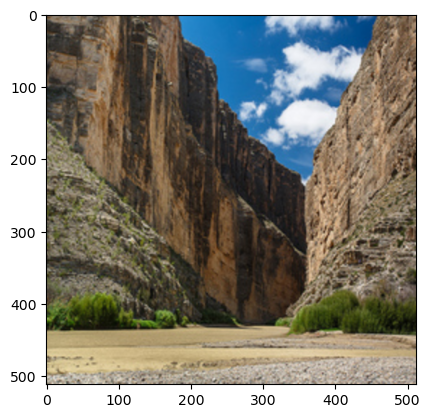

风格图像


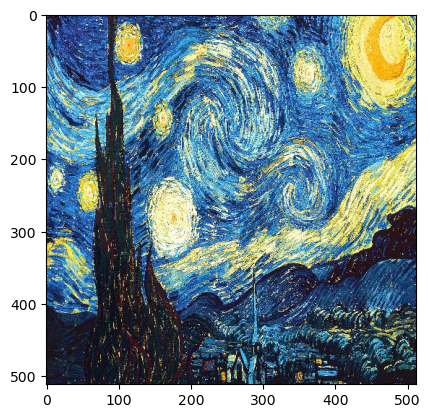

In [5]:
# 该工具包中有AlexNet、VGG等多种训练好的CNN网络
from torchvision import models 
import copy

# 定义图像处理方法
transform = transforms.Resize([512, 512]) # 规整图像形状

def loadimg(path):  
    # 加载路径为path的图像，形状为H*W*C
    img = plt.imread(path)
    # 处理图像，注意重排维度使通道维在最前
    img = transform(torch.tensor(img).permute(2, 0, 1))
    # 展示图像
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.show()
    # 添加batch size维度
    img = img.unsqueeze(0).to(dtype=torch.float32)
    img /= 255 # 将其值从0-255的整数转换为0-1的浮点数
    return img

content_image_path = os.path.join('style_transfer', 'content', '04.jpg')
style_image_path = os.path.join('style_transfer', 'style.jpg')

# 加载内容图像
print('内容图像')
content_img = loadimg(content_image_path)
# 加载风格图像
print('风格图像') 
style_img = loadimg(style_image_path)

In [6]:
# 内容损失
class ContentLoss(nn.Module):

    def __init__(self, target):
        # target为从目标图像中提取的内容特征
        super().__init__()
        # 我们不对target求梯度，因此将target从梯度的计算图中分离出来
        self.target = target.detach() 
        self.criterion = nn.MSELoss()

    def forward(self, x):
         # 利用MSE计算输入图像与目标内容图像之间的损失
        self.loss = self.criterion(x.clone(), self.target) 
        return x # 只计算损失，不改变输入

    def backward(self): 
        # 由于本模块只包含损失计算，不改变输入，因此要单独定义反向传播
        self.loss.backward(retain_graph=True)
        return self.loss


def gram(x):
    # 计算G矩阵
    batch_size, n, w, h = x.shape # n为卷积核数目，w和h为输出的宽和高
    f = x.view(batch_size * n, w * h) # 变换为二维
    g = f @ f.T / (batch_size * n * w * h) # 除以参数数目，进行归一化
    return g


# 风格损失
class StyleLoss(nn.Module):

    def __init__(self, target):
        # target为从目标图像中提取的风格特征
        # weight为设置的强度系数lambda
        super().__init__()
        self.target_gram = gram(target.detach()) # 目标的Gram矩阵
        self.criterion = nn.MSELoss()

    def forward(self, x):
        input_gram = gram(x.clone()) # 输入的Gram矩阵
        self.loss = self.criterion(input_gram, self.target_gram)
        return x

    def backward(self):
        self.loss.backward(retain_graph=True)
        return self.loss

In [7]:
vgg16 = models.vgg16(weights=True).features # 导入预训练的VGG16网络

# 选定用于提取特征的卷积层，Conv_13对应着第5块的第3卷积层
content_layer = ['Conv_13']
# 下面这些层分别对应第1至5块的第1卷积层
style_layer = ['Conv_1', 'Conv_3', 'Conv_5', 'Conv_8', 'Conv_11']

content_losses = [] # 内容损失
style_losses = [] # 风格损失

model = nn.Sequential() # 储存新模型的层
vgg16 = copy.deepcopy(vgg16)
index = 1  # 计数卷积层

# 遍历 VGG16 的网络结构，选取需要的层
for layer in list(vgg16):
    if isinstance(layer, nn.Conv2d): # 如果是卷积层
        name = "Conv_" + str(index)
        model.append(layer)
        if name in content_layer:  
            # 如果当前层用于抽取内容特征，则添加内容损失
            target = model(content_img).clone() # 计算内容图像的特征
            content_loss = ContentLoss(target) # 内容损失模块
            model.append(content_loss)
            content_losses.append(content_loss)

        if name in style_layer:  
            # 如果当前层用于抽取风格特征，则添加风格损失
            target = model(style_img).clone()
            style_loss = StyleLoss(target) # 风格损失模块
            model.append(style_loss)  
            style_losses.append(style_loss) 

    if isinstance(layer, nn.ReLU): # 如果激活函数层
        model.append(layer)
        index += 1

    if isinstance(layer, nn.MaxPool2d): # 如果是池化层
        model.append(layer)

# 输出模型结构
print(model)

F:\Anaconda3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): StyleLoss(
    (criterion): MSELoss()
  )
  (2): ReLU(inplace=True)
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): StyleLoss(
    (criterion): MSELoss()
  )
  (8): ReLU(inplace=True)
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): StyleLoss(
    (criterion): MSELoss()
  )
  (14): ReLU(inplace=True)
  (15): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (16): ReLU(inplace=True)
  (17): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1

训练轮数：0,	风格损失：11691.9434,	内容损失：0.0000


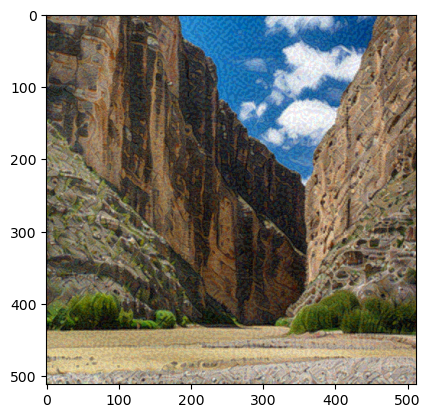

训练轮数：10,	风格损失：1227.6650,	内容损失：4.0906


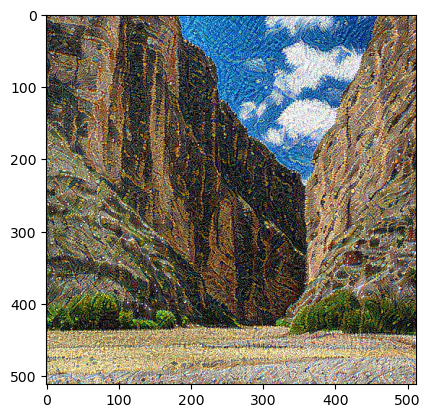

训练轮数：20,	风格损失：294.1203,	内容损失：4.5809


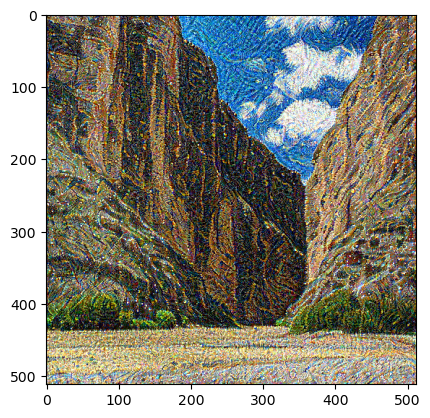

训练轮数：30,	风格损失：149.5464,	内容损失：3.9374


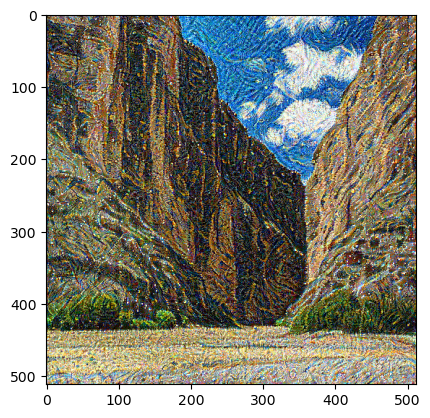

训练轮数：40,	风格损失：93.6983,	内容损失：3.6112


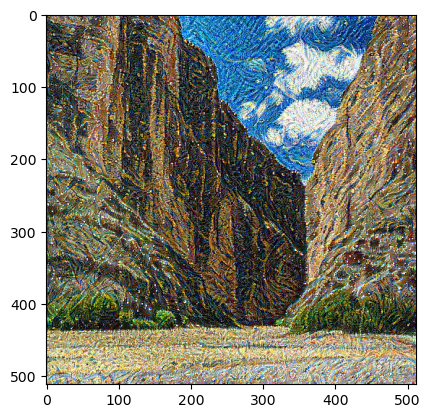

训练轮数：49,	风格损失：62.7592,	内容损失：3.3849


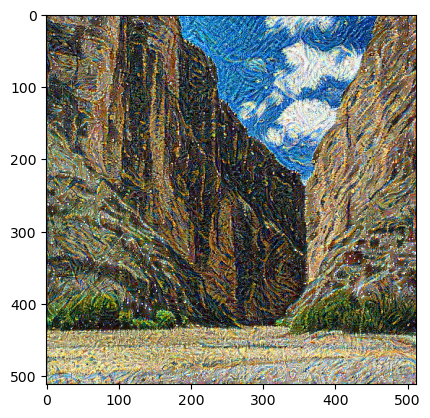

In [8]:
epochs = 50
learning_rate = 0.05
lbd = 1e6 # 强度系数

input_img = content_img.clone() # 从内容图像开始迁移
param = nn.Parameter(input_img.data) # 将图像内容设置为可训练的参数
optimizer = torch.optim.Adam([param], lr=learning_rate) # 使用Adam优化器

for i in range(epochs):
    style_score = 0  # 本轮的风格损失
    content_score = 0  # 本轮的内容损失
    model(param) # 将输入通过模型，得到损失
    for cl in content_losses:  
        content_score += cl.backward()
    for sl in style_losses:  
        style_score += sl.backward()
    style_score *= lbd
    loss = content_score + style_score
    # 更新输入图像
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # 每次对输入图像进行更新后
    # 图像中部分像素点会超出0-1的范围
    # 因此要对其进行剪切
    param.data.clamp_(0, 1) 

    if i % 10 == 0 or i == epochs - 1:
        print(f'训练轮数：{i},\t风格损失：{style_score.item():.4f},\t' \
            f'内容损失：{content_score.item():.4f}')
        plt.imshow(input_img[0].permute(1, 2, 0).numpy())
        plt.show()